# Notebook 08: Data Sufficiency


In [1]:
import json
import time
from pathlib import Path

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None

try:
    from pygam import LinearGAM, s, l
except ImportError:
    LinearGAM = None
    s = None
    l = None
    
    
import warnings
warnings.filterwarnings("ignore")

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent, cwd.parent.parent]
PROJECT_DIR = next((p for p in candidate_roots if (p / "requirements.txt").exists()), cwd)
DATA_DIR = PROJECT_DIR / "notebooks" / "data"
CLEAN_DIR = PROJECT_DIR / "clean_data"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"


## 1. Load Data & Setup

This notebook uses the same feature setup as the modeling notebooks. It is artifact-driven: if teammates save metadata in the same pattern under `artifacts/<model_name>/`, this notebook will discover and run the supported models automatically.


In [2]:
train = pd.read_csv(CLEAN_DIR / 'train.csv', parse_dates=['week_start'])
test = pd.read_csv(CLEAN_DIR / 'test.csv', parse_dates=['week_start'])

cat_cols = [c for c in train.columns if c.startswith('cat_id_')]
store_cols = [c for c in train.columns if c.startswith('store_id_')]

for df in [train, test]:
    df['cat_id'] = df[cat_cols].idxmax(axis=1).str.replace('cat_id_', '')
    df['store_id'] = df[store_cols].idxmax(axis=1).str.replace('store_id_', '')

target = 'weekly_units'
drop_cols = (['wm_yr_wk', 'week_start', 'n_days', 'month', 'week_of_year', 
              'cat_id', 'store_id', target]
             + cat_cols + store_cols 
             + [c for c in train.columns if c.startswith('state_id_')])
feature_cols = [c for c in train.columns if c not in drop_cols]

combos = sorted(train.groupby(['store_id', 'cat_id']).groups.keys())

train_full = train.copy()
sorted_train_weeks = sorted(train_full['wm_yr_wk'].unique())
val_weeks = sorted_train_weeks[-8:]
train_weeks = sorted_train_weeks[:-8]

train_tune = train_full[train_full['wm_yr_wk'].isin(train_weeks)].copy()
val = train_full[train_full['wm_yr_wk'].isin(val_weeks)].copy()

print('Train tuning shape:', train_tune.shape)
print('Validation shape:', val.shape)
print('Test shape:', test.shape)
print('Feature count:', len(feature_cols))
print('Combos:', len(combos))


Train tuning shape: (6270, 47)
Validation shape: (240, 47)
Test shape: (240, 47)
Feature count: 23
Combos: 30


## 2. Load Saved Artifacts


In [3]:
def load_metadata(path):
    path = Path(path)
    if not path.exists():
        return None
    with open(path, "r") as f:
        return json.load(f)

def load_artifact_bundle(path, metadata_path=None):
    if not path:
        return None, "artifact_file missing from metadata"
    candidates = [Path(path)]
    if metadata_path is not None:
        candidates.append(Path(metadata_path).parent / Path(path).name)
    existing_candidates = [bundle_path for bundle_path in candidates if bundle_path.exists()]
    if not existing_candidates:
        return None, f"artifact file not found: {path}"
    last_error = None
    for bundle_path in existing_candidates:
        try:
            return joblib.load(bundle_path), None
        except Exception as e:
            last_error = f"{type(e).__name__}: {e}"
    return None, last_error

artifact_roots = [ARTIFACTS_DIR, PROJECT_DIR / "artifacts"]
artifact_paths = []
seen_keys = set()
for root in artifact_roots:
    if not root.exists():
        continue
    for meta_path in sorted(root.glob("*/*_metadata.json")):
        artifact_key = meta_path.parent.name
        if artifact_key not in seen_keys:
            artifact_paths.append(meta_path)
            seen_keys.add(artifact_key)

artifact_registry = {}
registry_rows = []

for metadata_path in artifact_paths:
    meta = load_metadata(metadata_path)
    if meta is None:
        continue
    artifact_key = metadata_path.parent.name
    model_type = meta.get("model_type", artifact_key)
    artifact_file = meta.get("artifact_file")
    bundle, bundle_error = load_artifact_bundle(artifact_file, metadata_path=metadata_path)
    artifact_registry[artifact_key] = {"metadata": meta, "bundle": bundle, "bundle_error": bundle_error, "metadata_file": str(metadata_path), "artifact_file": artifact_file, "model_type": model_type}
    registry_rows.append({
        "artifact_key": artifact_key,
        "model_name": meta.get("model_name", artifact_key),
        "model_type": model_type,
        "metadata_file": str(metadata_path),
        "artifact_file": artifact_file,
        "bundle_loaded": bundle is not None,
        "bundle_error": bundle_error
    })

if not artifact_registry:
    raise FileNotFoundError("No saved model artifacts were found under ../artifacts/*/ or artifacts/*/.")

artifact_summary = pd.DataFrame(registry_rows).sort_values(["artifact_key", "metadata_file"]).reset_index(drop=True)
print("Loaded artifact entries:", list(artifact_registry.keys()))
artifact_summary


Loaded artifact entries: ['gam', 'lightgbm', 'mlp', 'random_forest', 'ridge']


,artifact_key,model_name,model_type,metadata_file,artifact_file,bundle_loaded,bundle_error
0,gam,GAM (Plain Vanilla),gam,../artifacts/gam/gam_metadata.json,/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705...,True,None
1,lightgbm,LightGBM (Pooled),lightgbm,../artifacts/lightgbm/lightgbm_metadata.json,/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705...,True,None
2,mlp,MLP Final,mlp,../artifacts/mlp/mlp_metadata.json,/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705...,True,None
3,random_forest,RandomForest (Pooled),random_forest,../artifacts/random_forest/random_forest_metad...,/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705...,True,None
4,ridge,Ridge (CV alpha),ridge_cv,../artifacts/ridge/ridge_metadata.json,/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705...,True,None


## 3. Experiment Questions

This notebook is answering three questions for each supported model artifact it finds:

1. Can the saved fitted artifacts still be loaded and used directly for prediction?
2. How much historical training data is needed before performance becomes reasonably stable?
3. Does concentrating on the highest-volume store-category combinations preserve enough signal relative to the full training set?

Subsetting design:
- We do not randomly sample rows, because that would break the forecasting structure.
- For size experiments, we use repeated contiguous week windows shared across all series.
- For concentration experiments, we use a deterministic Pareto subset based on combo volume.
- The saved fitted bundles are used for a direct sanity check, but the sufficiency experiments intentionally retrain from each model's saved best configuration.


## 4. Metrics and Generic Runners


In [4]:
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    safe_y_true = np.where(np.asarray(y_true) == 0, np.nan, np.asarray(y_true))
    mape = np.nanmean(np.abs((np.asarray(y_true) - np.asarray(y_pred)) / safe_y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

def summarize_runtime(seconds, n_models):
    return {"fit_time_total_sec": seconds, "fit_time_avg_sec": seconds / n_models if n_models else np.nan}

def mlp_param_count(input_dim, hidden_layer_sizes):
    dims = [input_dim] + list(hidden_layer_sizes) + [1]
    total = 0
    for in_dim, out_dim in zip(dims[:-1], dims[1:]):
        total += in_dim * out_dim + out_dim
    return total

def make_contiguous_week_subsets(df, fraction, n_repeats=5):
    weeks = sorted(df["wm_yr_wk"].unique())
    keep_n = max(1, int(np.floor(len(weeks) * fraction)))
    if keep_n >= len(weeks):
        return [(0, df.copy())]
    max_start = len(weeks) - keep_n
    starts = np.linspace(0, max_start, num=min(n_repeats, max_start + 1), dtype=int)
    starts = sorted(set(starts.tolist()))
    subsets = []
    for repeat_id, start in enumerate(starts):
        keep_weeks = weeks[start:start + keep_n]
        subset = df[df["wm_yr_wk"].isin(keep_weeks)].copy()
        subsets.append((repeat_id, subset))
    return subsets

def pareto_subset_by_combo_volume(df, top_share=0.8):
    volume = df.groupby(["store_id", "cat_id"])[target].sum().sort_values(ascending=False).reset_index(name="volume")
    volume["cum_share"] = volume["volume"].cumsum() / volume["volume"].sum()
    keep = volume[volume["cum_share"] <= top_share].copy()
    if keep.empty:
        keep = volume.head(1).copy()
    return df.merge(keep[["store_id", "cat_id"]], on=["store_id", "cat_id"], how="inner")

def get_model_spec(metadata, artifact_key):
    model_type = metadata.get("model_type", artifact_key)
    model_scope = metadata.get("model_scope", "per_combo")
    model_target = metadata.get("target", target)
    model_feature_cols = metadata.get("feature_cols", feature_cols)
    best_config = metadata.get("best_config", {})
    return model_type, model_scope, model_target, model_feature_cols, best_config

def build_gam_model(model_feature_cols, best_config):
    if LinearGAM is None or s is None or l is None:
        raise ImportError("pygam is not installed in this environment.")
    smooth_cols = set(best_config.get("smooth_cols", []))
    terms = None
    for idx, col in enumerate(model_feature_cols):
        term = s(idx) if col in smooth_cols else l(idx)
        terms = term if terms is None else terms + term
    return LinearGAM(terms)

def build_model(model_type, best_config, model_feature_cols, random_state=42):
    if model_type == "mlp":
        return MLPRegressor(hidden_layer_sizes=tuple(best_config["hidden_layer_sizes"]), activation="relu", alpha=best_config["alpha"], learning_rate_init=0.001, max_iter=1000, early_stopping=True, validation_fraction=0.15, random_state=random_state)
    if model_type == "ridge_cv":
        return RidgeCV(alphas=np.array(best_config["alphas"]), cv=best_config["cv"])
    if model_type == "random_forest":
        return RandomForestRegressor(**best_config, n_jobs=-1, random_state=random_state)
    if model_type == "lightgbm":
        if LGBMRegressor is None:
            raise ImportError("lightgbm is not installed in this environment.")
        return LGBMRegressor(**best_config, random_state=random_state, verbose=-1)
    if model_type == "gam":
        return build_gam_model(model_feature_cols, best_config)
    raise ValueError(f"Unsupported model_type: {model_type}")

def run_supported_model(train_df, eval_df, metadata, model_key, random_state=42):
    model_type, model_scope, model_target, model_feature_cols, best_config = get_model_spec(metadata, model_key)
    if model_scope == "pooled":
        X_tr = train_df[model_feature_cols]
        y_tr = train_df[model_target]
        X_ev = eval_df[model_feature_cols]
        y_ev = eval_df[model_target]
        model = build_model(model_type, best_config, model_feature_cols, random_state=random_state)
        start = time.perf_counter()
        if model_type == "gam":
            model.fit(X_tr.values, y_tr.values)
            preds = model.predict(X_ev.values)
        else:
            model.fit(X_tr, y_tr)
            preds = model.predict(X_ev)
        fit_seconds = time.perf_counter() - start
        pred_df = eval_df[["week_start", "store_id", "cat_id"]].copy()
        pred_df["actual"] = y_ev.values
        pred_df["predicted"] = preds
        overall = calc_metrics(pred_df["actual"], pred_df["predicted"])
        overall.update(summarize_runtime(fit_seconds, 1))
        overall["estimated_params_per_model"] = np.nan
        overall["estimated_total_params"] = np.nan
        overall["active_models"] = 1
        overall["model_type"] = model_type
        overall["model_scope"] = model_scope
        combo_df = pred_df.groupby(["store_id", "cat_id"]).apply(lambda g: pd.Series(calc_metrics(g["actual"], g["predicted"]))).reset_index()
        print(f"{metadata.get('model_name', model_key):32s}  MAE={overall['MAE']:>7,.0f}  RMSE={overall['RMSE']:>7,.0f}  MAPE={overall['MAPE']:>5.1f}%  R²={overall['R2']:.4f}")
        return pred_df, combo_df, overall

    all_preds = []
    combo_results = []
    fit_seconds = 0.0
    active_combos = sorted(train_df.groupby(["store_id", "cat_id"]).groups.keys())
    estimated_params_per_model = mlp_param_count(len(model_feature_cols), best_config["hidden_layer_sizes"]) if model_type == "mlp" else np.nan
    for store, cat in active_combos:
        tr = train_df[(train_df["store_id"] == store) & (train_df["cat_id"] == cat)]
        ev = eval_df[(eval_df["store_id"] == store) & (eval_df["cat_id"] == cat)]
        if tr.empty or ev.empty:
            continue
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(tr[model_feature_cols])
        X_ev_s = scaler.transform(ev[model_feature_cols])
        model = build_model(model_type, best_config, model_feature_cols, random_state=random_state)
        start = time.perf_counter()
        model.fit(X_tr_s, tr[model_target])
        fit_seconds += time.perf_counter() - start
        preds = model.predict(X_ev_s)
        metrics = calc_metrics(ev[model_target], preds)
        metrics["store_id"] = store
        metrics["cat_id"] = cat
        combo_results.append(metrics)
        pred_df = ev[["week_start", "store_id", "cat_id"]].copy()
        pred_df["actual"] = ev[model_target].values
        pred_df["predicted"] = preds
        all_preds.append(pred_df)
    if not all_preds:
        raise ValueError(f"No predictions were produced for {metadata.get('model_name', model_key)}.")
    all_preds_df = pd.concat(all_preds, ignore_index=True)
    combo_df = pd.DataFrame(combo_results)
    overall = calc_metrics(all_preds_df["actual"], all_preds_df["predicted"])
    overall.update(summarize_runtime(fit_seconds, len(combo_df)))
    overall["estimated_params_per_model"] = estimated_params_per_model
    overall["estimated_total_params"] = estimated_params_per_model * len(combo_df) if pd.notna(estimated_params_per_model) else np.nan
    overall["active_models"] = len(combo_df)
    overall["model_type"] = model_type
    overall["model_scope"] = model_scope
    print(f"{metadata.get('model_name', model_key):32s}  MAE={overall['MAE']:>7,.0f}  RMSE={overall['RMSE']:>7,.0f}  MAPE={overall['MAPE']:>5.1f}%  R²={overall['R2']:.4f}")
    return all_preds_df, combo_df, overall

supported_model_types = {"mlp", "ridge_cv", "random_forest", "lightgbm", "gam"}
supported_artifacts = {k: v for k, v in artifact_registry.items() if v["model_type"] in supported_model_types}
unsupported_artifacts = {k: v for k, v in artifact_registry.items() if v["model_type"] not in supported_model_types}
print("Supported models:", list(supported_artifacts.keys()))
print("Unsupported models:", list(unsupported_artifacts.keys()))


Supported models: ['gam', 'lightgbm', 'mlp', 'random_forest', 'ridge']
Unsupported models: []


## 2A. Saved Model Sanity Check

Load the saved fitted bundles directly and verify that they can still generate predictions on the held-out test set. This gives us a quick artifact integrity check before the data-sufficiency notebook retrains the same saved model specs on smaller subsets.


In [5]:
def evaluate_saved_bundle(eval_df, artifact_entry, artifact_key):
    metadata = artifact_entry["metadata"]
    bundle = artifact_entry["bundle"]
    model_name = metadata.get("model_name", artifact_key)
    model_type, model_scope, model_target, model_feature_cols, _ = get_model_spec(metadata, artifact_key)
    if bundle is None:
        raise FileNotFoundError(f"Saved bundle missing for {artifact_key}: {artifact_entry.get('bundle_error') or artifact_entry.get('artifact_file')}")
    if model_scope == "pooled":
        bundle_feature_cols = None
        if hasattr(bundle, "feature_name_") and getattr(bundle, "feature_name_", None):
            candidate_cols = list(bundle.feature_name_)
            if set(candidate_cols).issubset(eval_df.columns):
                bundle_feature_cols = candidate_cols
        elif hasattr(bundle, "feature_names_in_") and getattr(bundle, "feature_names_in_", None) is not None:
            candidate_cols = list(bundle.feature_names_in_)
            if set(candidate_cols).issubset(eval_df.columns):
                bundle_feature_cols = candidate_cols
        use_feature_cols = bundle_feature_cols or model_feature_cols
        if not set(use_feature_cols).issubset(eval_df.columns):
            missing_cols = sorted(set(use_feature_cols) - set(eval_df.columns))
            raise KeyError(f"Missing evaluation columns for {artifact_key}: {missing_cols[:10]}")
        if model_type == "gam":
            preds = bundle.predict(eval_df[use_feature_cols].values)
        else:
            preds = bundle.predict(eval_df[use_feature_cols])
        preds_df = eval_df[["week_start", "store_id", "cat_id"]].copy()
        preds_df["actual"] = eval_df[model_target].values
        preds_df["predicted"] = preds
    else:
        pred_frames = []
        for combo_key, obj in bundle.items():
            store, cat = combo_key.split("__", 1)
            ev = eval_df[(eval_df["store_id"] == store) & (eval_df["cat_id"] == cat)]
            if ev.empty:
                continue
            scaler = obj["scaler"]
            model = obj["model"]
            preds = model.predict(scaler.transform(ev[model_feature_cols]))
            pred_df = ev[["week_start", "store_id", "cat_id"]].copy()
            pred_df["actual"] = ev[model_target].values
            pred_df["predicted"] = preds
            pred_frames.append(pred_df)
        if not pred_frames:
            raise ValueError(f"No overlapping combo predictions were produced for {artifact_key}.")
        preds_df = pd.concat(pred_frames, ignore_index=True)
    metrics = calc_metrics(preds_df["actual"], preds_df["predicted"])
    metrics["artifact_key"] = artifact_key
    metrics["model_name"] = model_name
    metrics["model_type"] = artifact_entry["model_type"]
    metrics["model_scope"] = model_scope
    metrics["prediction_rows"] = len(preds_df)
    return metrics

saved_model_rows = []
saved_model_errors = []
for artifact_key, entry in artifact_registry.items():
    if entry["bundle"] is None:
        saved_model_errors.append({
            "artifact_key": artifact_key,
            "model_name": entry["metadata"].get("model_name", artifact_key),
            "reason": entry.get("bundle_error") or "bundle not found"
        })
        print(f"Skipped saved-model evaluation for {artifact_key}: {entry.get('bundle_error') or 'bundle not found'}")
        continue
    try:
        saved_model_rows.append(evaluate_saved_bundle(test, entry, artifact_key))
    except Exception as e:
        saved_model_errors.append({
            "artifact_key": artifact_key,
            "model_name": entry["metadata"].get("model_name", artifact_key),
            "reason": str(e)
        })
        print(f"Skipped saved-model evaluation for {artifact_key}: {e}")

saved_model_eval_df = pd.DataFrame(saved_model_rows).round({"MAE": 0, "RMSE": 0, "MAPE": 1, "R2": 4}) if saved_model_rows else pd.DataFrame()
saved_model_error_df = pd.DataFrame(saved_model_errors)
print(f"Saved-model checks completed: {len(saved_model_rows)} succeeded, {len(saved_model_errors)} skipped.")
saved_model_eval_df


Saved-model checks completed: 5 succeeded, 0 skipped.


,MAE,RMSE,MAPE,R2,artifact_key,model_name,model_type,model_scope,prediction_rows
0,596.0,957.0,7.3,0.9860,gam,GAM (Plain Vanilla),gam,pooled,240
1,430.0,771.0,4.4,0.9909,lightgbm,LightGBM (Pooled),lightgbm,pooled,240
2,4816.0,8827.0,32.0,-0.1916,mlp,MLP Final,mlp,per_combo,240
3,443.0,807.0,4.4,0.9900,random_forest,RandomForest (Pooled),random_forest,pooled,240
4,406.0,756.0,4.2,0.9913,ridge,Ridge (CV alpha),ridge_cv,per_combo,240


## 5. Data Size Experiments

For every supported saved model, run repeated contiguous training-window subsets at `25%`, `50%`, `75%`, and `100%` of the training history.


In [6]:
fraction_rows = []

for artifact_key, entry in supported_artifacts.items():
    meta = entry["metadata"]
    for frac in [0.25, 0.50, 0.75, 1.00]:
        subsets = make_contiguous_week_subsets(train_tune, frac, n_repeats=5)
        for repeat_id, subset in subsets:
            _, _, res = run_supported_model(subset, val, meta, artifact_key, random_state=42 + repeat_id)
            fraction_rows.append({
                "artifact_key": artifact_key,
                "model_name": meta.get("model_name", artifact_key),
                "model_type": entry["model_type"],
                "model_scope": meta.get("model_scope", "per_combo"),
                "train_fraction": frac,
                "repeat_id": repeat_id,
                "subset_type": "contiguous_window",
                **res
            })

fraction_runs_df = pd.DataFrame(fraction_rows)
fraction_runs_df = fraction_runs_df.round({"MAE": 0, "RMSE": 0, "MAPE": 1, "R2": 4, "fit_time_total_sec": 3, "fit_time_avg_sec": 3})
fraction_runs_df.head()


GAM (Plain Vanilla)               MAE=  2,515  RMSE=  2,677  MAPE= 51.3%  R²=0.8828
GAM (Plain Vanilla)               MAE=  3,170  RMSE=  3,276  MAPE= 60.3%  R²=0.8245
GAM (Plain Vanilla)               MAE=  1,088  RMSE=  1,335  MAPE= 19.5%  R²=0.9708
GAM (Plain Vanilla)               MAE=    865  RMSE=  1,417  MAPE=  9.3%  R²=0.9672
GAM (Plain Vanilla)               MAE=    599  RMSE=  1,004  MAPE=  7.5%  R²=0.9835
GAM (Plain Vanilla)               MAE= 14,097  RMSE= 14,126  MAPE=284.5%  R²=-2.2638
GAM (Plain Vanilla)               MAE=  2,852  RMSE=  2,951  MAPE= 53.8%  R²=0.8575
GAM (Plain Vanilla)               MAE=  6,761  RMSE=  6,813  MAPE=139.3%  R²=0.2407
GAM (Plain Vanilla)               MAE=    790  RMSE=    988  MAPE= 14.0%  R²=0.9840
GAM (Plain Vanilla)               MAE=    619  RMSE=    819  MAPE= 10.5%  R²=0.9890
GAM (Plain Vanilla)               MAE=  5,664  RMSE=  5,723  MAPE=116.6%  R²=0.4642
GAM (Plain Vanilla)               MAE=    500  RMSE=    748  MAPE=  6.6%  R

,artifact_key,model_name,model_type,model_scope,train_fraction,repeat_id,subset_type,MAE,RMSE,MAPE,R2,fit_time_total_sec,fit_time_avg_sec,estimated_params_per_model,estimated_total_params,active_models
0,gam,GAM (Plain Vanilla),gam,pooled,0.25,0,contiguous_window,2515.0,2677.0,51.3,0.8828,0.318,0.318,NaN,NaN,1
1,gam,GAM (Plain Vanilla),gam,pooled,0.25,1,contiguous_window,3170.0,3276.0,60.3,0.8245,0.332,0.332,NaN,NaN,1
2,gam,GAM (Plain Vanilla),gam,pooled,0.25,2,contiguous_window,1088.0,1335.0,19.5,0.9708,0.389,0.389,NaN,NaN,1
3,gam,GAM (Plain Vanilla),gam,pooled,0.25,3,contiguous_window,865.0,1417.0,9.3,0.9672,0.352,0.352,NaN,NaN,1
4,gam,GAM (Plain Vanilla),gam,pooled,0.25,4,contiguous_window,599.0,1004.0,7.5,0.9835,0.366,0.366,NaN,NaN,1


In [7]:
fraction_summary_df = (
    fraction_runs_df
    .groupby(['artifact_key', 'model_name', 'train_fraction'])
    .agg(
        RMSE_mean=('RMSE', 'mean'),
        RMSE_std=('RMSE', 'std'),
        MAE_mean=('MAE', 'mean'),
        MAE_std=('MAE', 'std'),
        MAPE_mean=('MAPE', 'mean'),
        MAPE_std=('MAPE', 'std'),
        fit_time_total_sec_mean=('fit_time_total_sec', 'mean'),
        fit_time_total_sec_std=('fit_time_total_sec', 'std')
    )
    .reset_index()
    .round(3)
)
fraction_summary_df


,artifact_key,model_name,train_fraction,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std,fit_time_total_sec_mean,fit_time_total_sec_std
0,gam,GAM (Plain Vanilla),0.25,1941.8,980.268,1647.4,1128.634,29.58,24.576,0.351,0.028
1,gam,GAM (Plain Vanilla),0.50,5139.4,5573.352,5023.8,5643.245,100.42,115.244,0.510,0.035
2,gam,GAM (Plain Vanilla),0.75,1803.0,2191.962,1624.0,2261.248,31.30,47.838,0.730,0.053
3,gam,GAM (Plain Vanilla),1.00,917.0,NaN,763.0,NaN,14.60,NaN,1.033,NaN
4,lightgbm,LightGBM (Pooled),0.25,1093.2,131.033,641.6,71.863,6.28,0.646,0.066,0.013
5,lightgbm,LightGBM (Pooled),0.50,900.0,110.625,531.4,61.557,5.50,0.430,0.079,0.008
6,lightgbm,LightGBM (Pooled),0.75,806.0,68.202,469.2,33.774,5.20,0.436,0.149,0.070
7,lightgbm,LightGBM (Pooled),1.00,716.0,NaN,413.0,NaN,4.50,NaN,0.324,NaN
8,mlp,MLP Final,0.25,8585.2,1374.478,5997.2,1094.768,64.92,17.866,30.083,1.149
9,mlp,MLP Final,0.50,7936.4,1410.155,5275.6,998.938,49.86,10.406,33.200,3.142


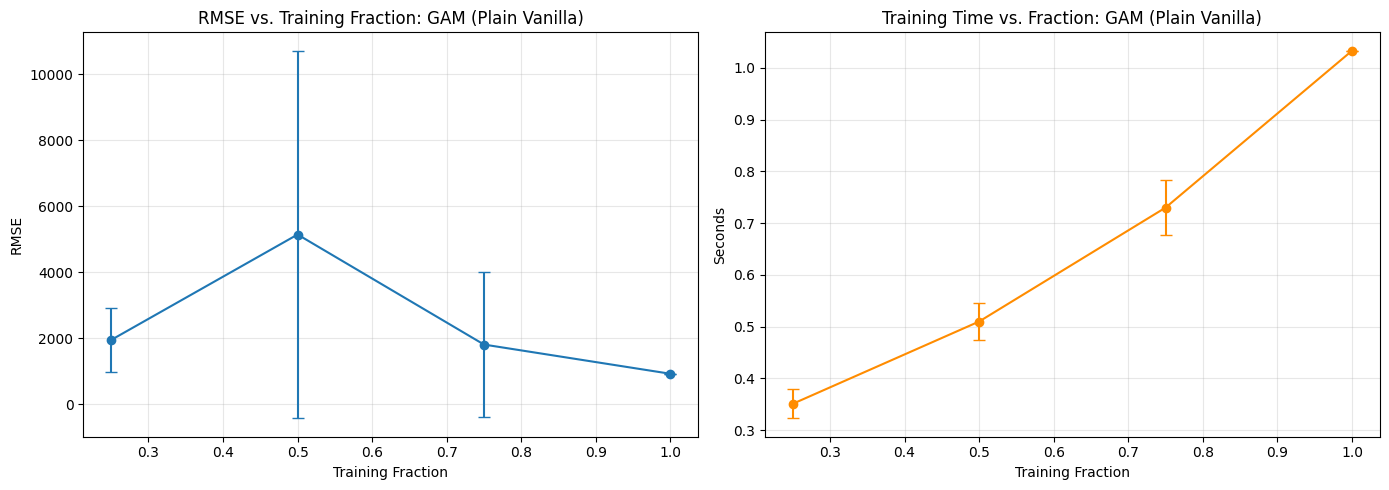

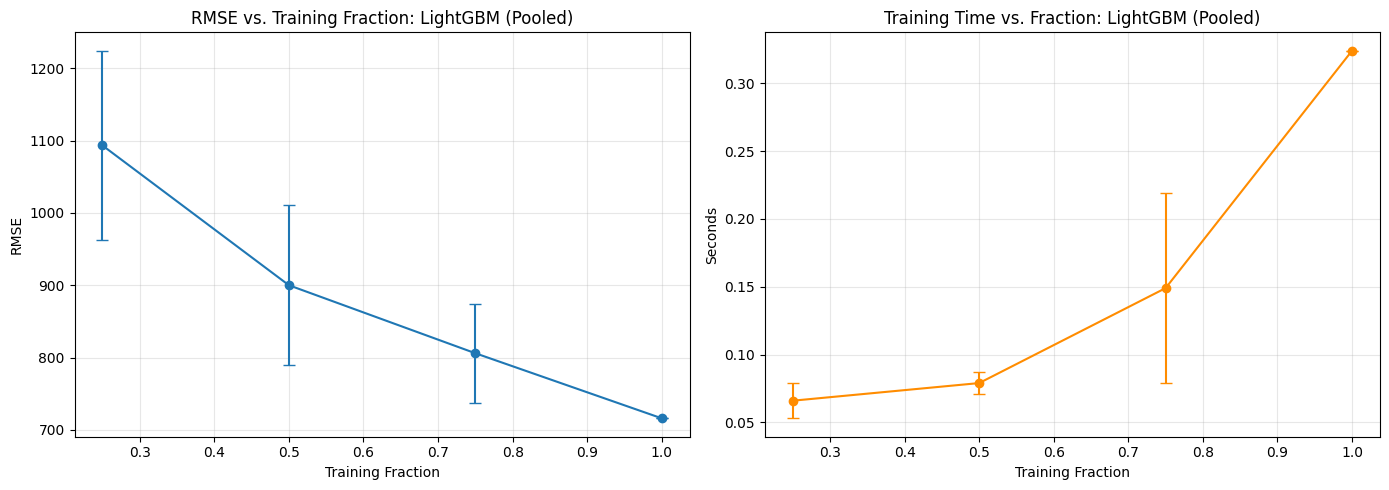

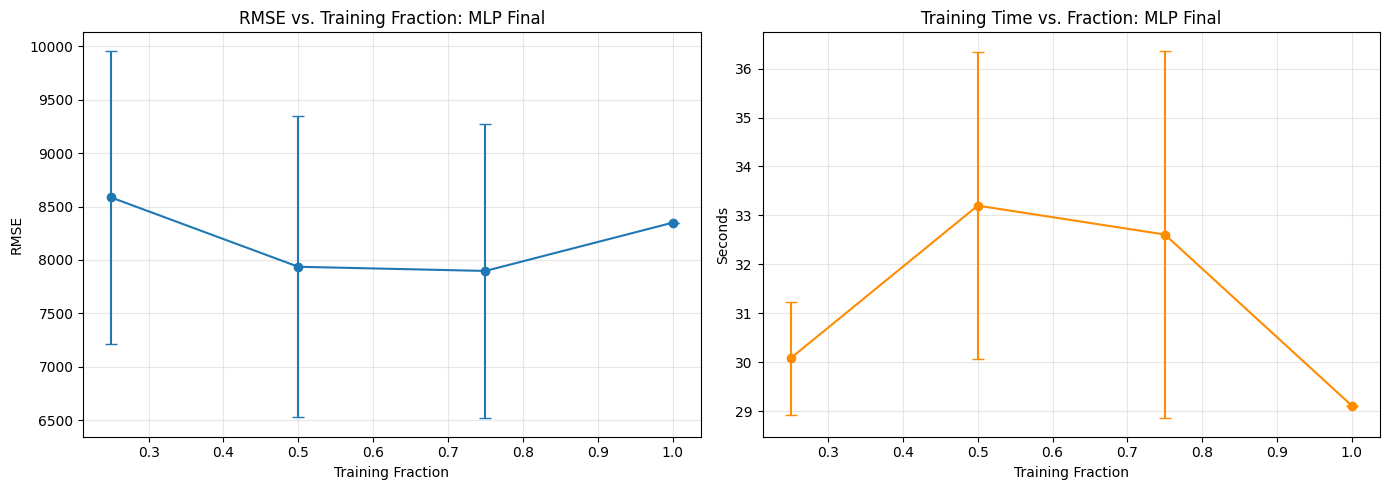

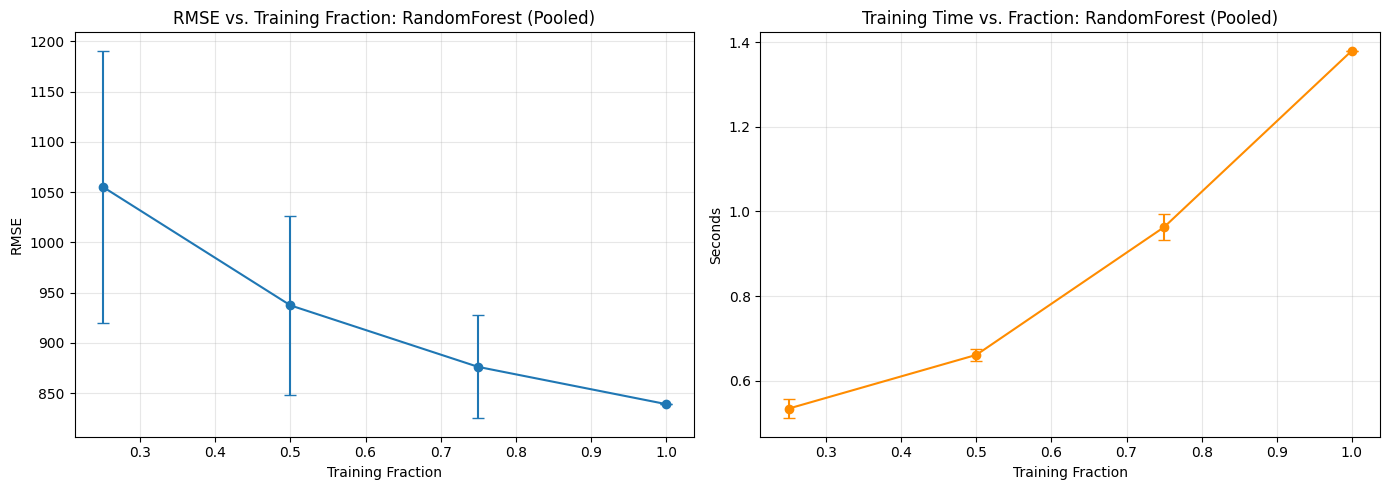

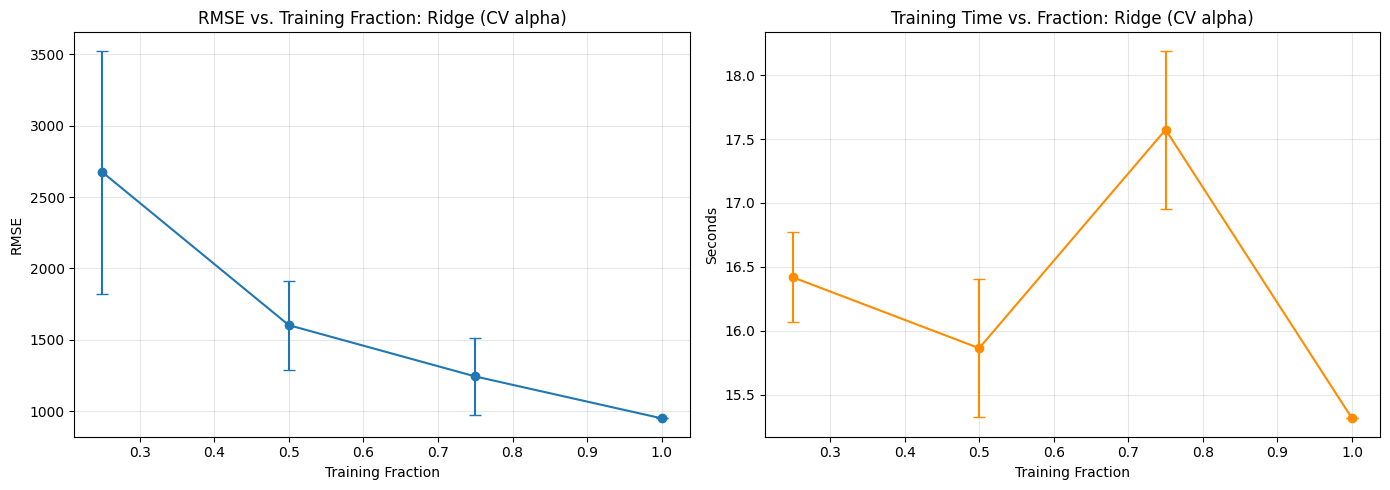

In [8]:
for model_name, group in fraction_summary_df.groupby('model_name'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].errorbar(group['train_fraction'], group['RMSE_mean'],
                     yerr=group['RMSE_std'].fillna(0), marker='o', capsize=4)
    axes[0].set_title(f'RMSE vs. Training Fraction: {model_name}')
    axes[0].set_xlabel('Training Fraction')
    axes[0].set_ylabel('RMSE')
    axes[0].grid(alpha=0.3)

    axes[1].errorbar(group['train_fraction'], group['fit_time_total_sec_mean'],
                     yerr=group['fit_time_total_sec_std'].fillna(0), marker='o', capsize=4, color='darkorange')
    axes[1].set_title(f'Training Time vs. Fraction: {model_name}')
    axes[1].set_xlabel('Training Fraction')
    axes[1].set_ylabel('Seconds')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


## 6. Pareto vs Full Data

For every supported saved model, compare the full training set against a Pareto subset of the highest-volume store-category combinations.


In [9]:
pareto_train = pareto_subset_by_combo_volume(train_tune, top_share=0.8)

pareto_rows = []
for artifact_key, entry in supported_artifacts.items():
    meta = entry["metadata"]
    for name, subset_type, subset in [
        (f"{meta.get("model_name", artifact_key)} Pareto 80", "pareto_80", pareto_train),
        (f"{meta.get("model_name", artifact_key)} Full", "full", train_tune)
    ]:
        _, _, res = run_supported_model(subset, val, meta, artifact_key, random_state=42)
        pareto_rows.append({
            "artifact_key": artifact_key,
            "model_name": meta.get("model_name", artifact_key),
            "subset_label": name,
            "subset_type": subset_type,
            **res
        })

pareto_df = pd.DataFrame(pareto_rows)
pareto_df = pareto_df.round({"MAE": 0, "RMSE": 0, "MAPE": 1, "R2": 4, "fit_time_total_sec": 3, "fit_time_avg_sec": 3})
pareto_df


GAM (Plain Vanilla)               MAE=    915  RMSE=  1,113  MAPE= 16.5%  R²=0.9797
GAM (Plain Vanilla)               MAE=    763  RMSE=    917  MAPE= 14.6%  R²=0.9863
LightGBM (Pooled)                 MAE=    903  RMSE=  1,195  MAPE= 25.4%  R²=0.9766
LightGBM (Pooled)                 MAE=    413  RMSE=    716  MAPE=  4.5%  R²=0.9916
MLP Final                         MAE=  9,455  RMSE= 12,153  MAPE= 51.2%  R²=-2.3222
MLP Final                         MAE=  4,843  RMSE=  8,349  MAPE= 34.3%  R²=-0.1402
RandomForest (Pooled)             MAE=    804  RMSE=  1,106  MAPE= 20.3%  R²=0.9800
RandomForest (Pooled)             MAE=    473  RMSE=    839  MAPE=  5.0%  R²=0.9885
Ridge (CV alpha)                  MAE=    888  RMSE=  1,321  MAPE=  5.0%  R²=0.9608
Ridge (CV alpha)                  MAE=    539  RMSE=    949  MAPE=  5.3%  R²=0.9853


,artifact_key,model_name,subset_label,subset_type,MAE,RMSE,MAPE,R2,fit_time_total_sec,fit_time_avg_sec,estimated_params_per_model,estimated_total_params,active_models,model_type,model_scope
0,gam,GAM (Plain Vanilla),GAM (Plain Vanilla) Pareto 80,pareto_80,915.0,1113.0,16.5,0.9797,0.382,0.382,NaN,NaN,1,gam,pooled
1,gam,GAM (Plain Vanilla),GAM (Plain Vanilla) Full,full,763.0,917.0,14.6,0.9863,0.650,0.650,NaN,NaN,1,gam,pooled
2,lightgbm,LightGBM (Pooled),LightGBM (Pooled) Pareto 80,pareto_80,903.0,1195.0,25.4,0.9766,0.045,0.045,NaN,NaN,1,lightgbm,pooled
3,lightgbm,LightGBM (Pooled),LightGBM (Pooled) Full,full,413.0,716.0,4.5,0.9916,0.057,0.057,NaN,NaN,1,lightgbm,pooled
4,mlp,MLP Final,MLP Final Pareto 80,pareto_80,9455.0,12153.0,51.2,-2.3222,11.623,0.830,1313.0,18382.0,14,mlp,per_combo
5,mlp,MLP Final,MLP Final Full,full,4843.0,8349.0,34.3,-0.1402,25.067,0.836,1313.0,39390.0,30,mlp,per_combo
6,random_forest,RandomForest (Pooled),RandomForest (Pooled) Pareto 80,pareto_80,804.0,1106.0,20.3,0.9800,0.628,0.628,NaN,NaN,1,random_forest,pooled
7,random_forest,RandomForest (Pooled),RandomForest (Pooled) Full,full,473.0,839.0,5.0,0.9885,1.261,1.261,NaN,NaN,1,random_forest,pooled
8,ridge,Ridge (CV alpha),Ridge (CV alpha) Pareto 80,pareto_80,888.0,1321.0,5.0,0.9608,6.673,0.477,NaN,NaN,14,ridge_cv,per_combo
9,ridge,Ridge (CV alpha),Ridge (CV alpha) Full,full,539.0,949.0,5.3,0.9853,13.499,0.450,NaN,NaN,30,ridge_cv,per_combo


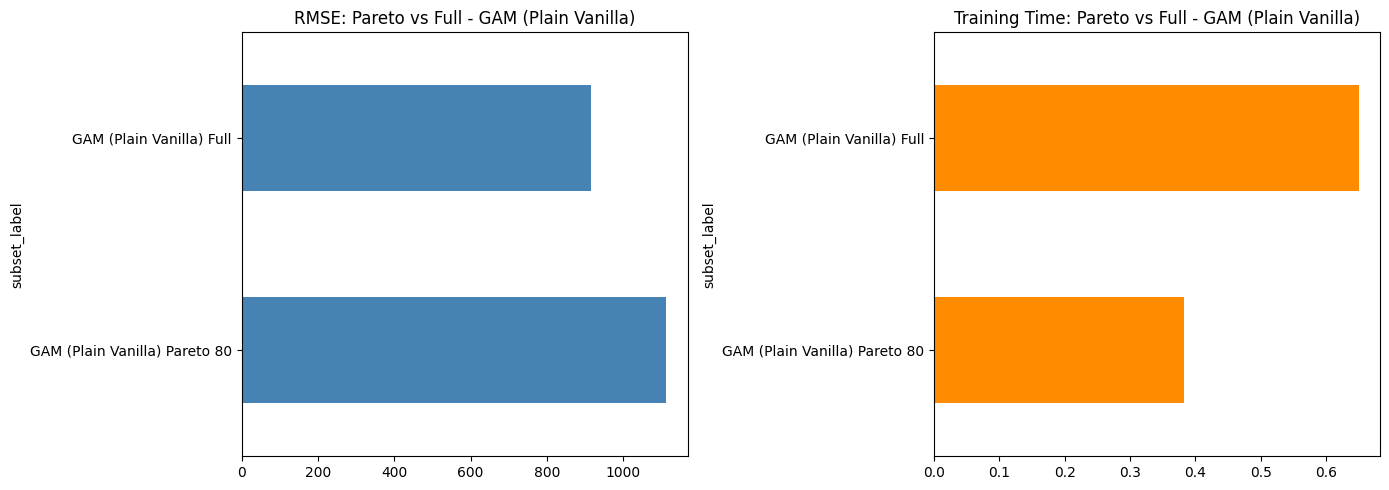

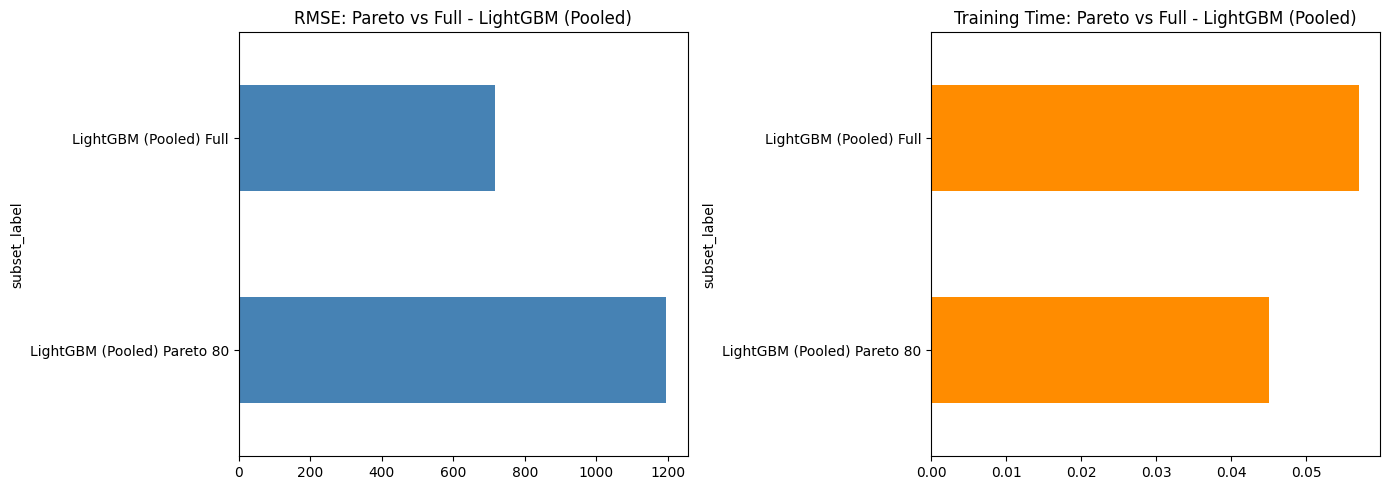

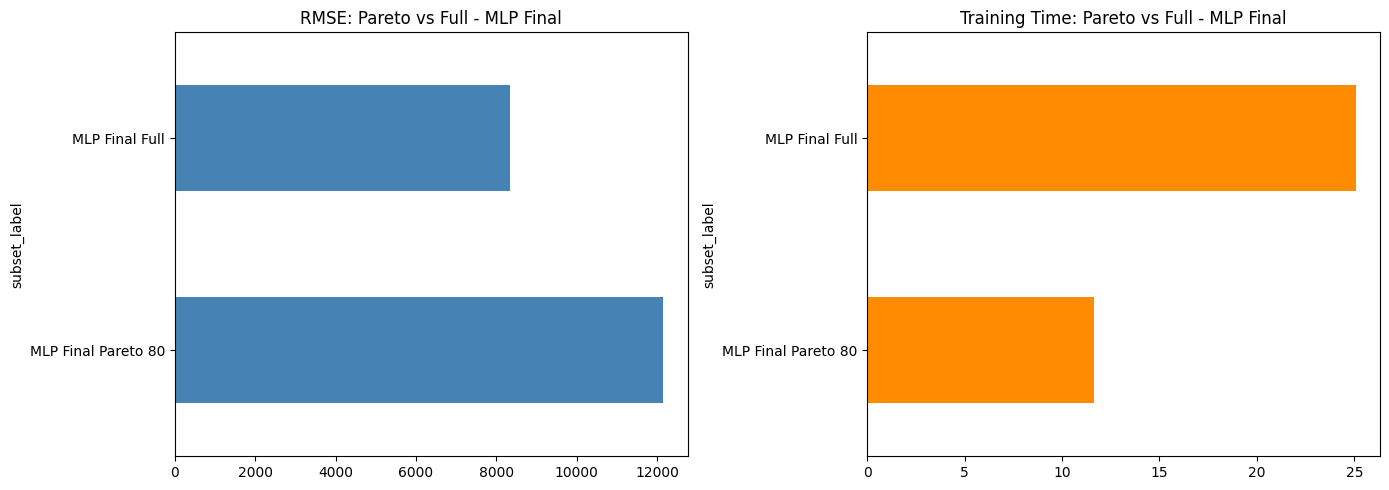

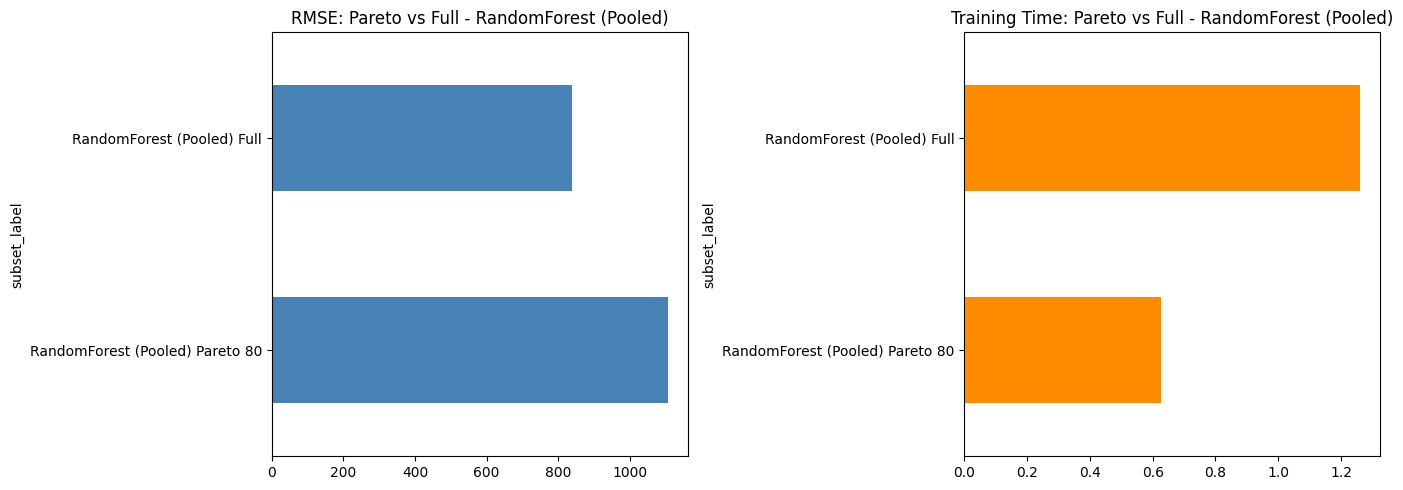

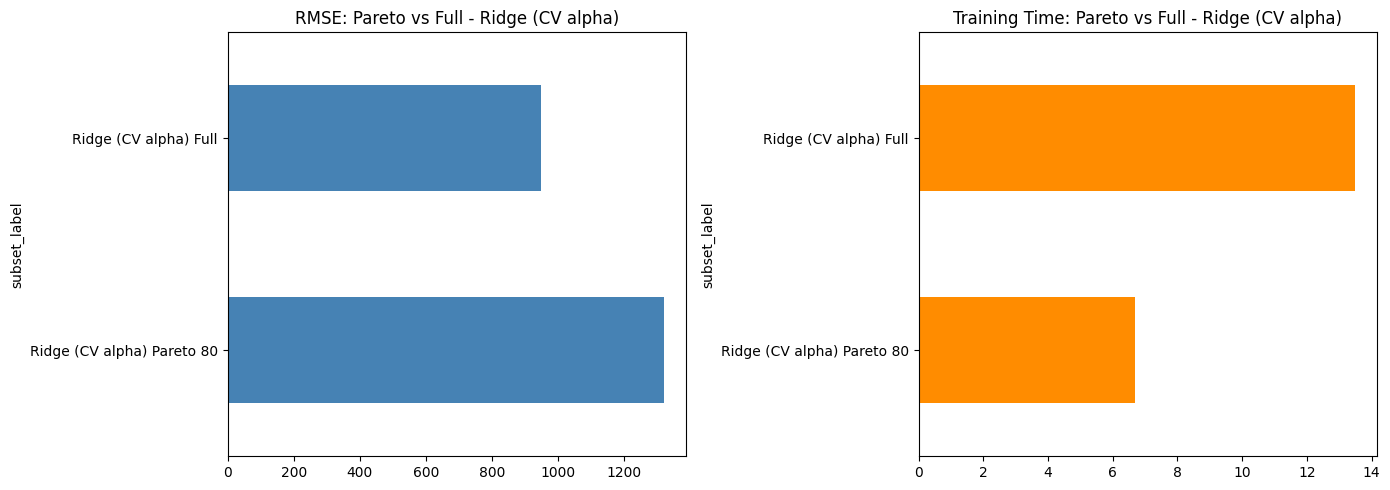

In [10]:
for model_name, group in pareto_df.groupby('model_name'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    group.set_index('subset_label')['RMSE'].plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title(f'RMSE: Pareto vs Full - {model_name}')

    group.set_index('subset_label')['fit_time_total_sec'].plot(kind='barh', ax=axes[1], color='darkorange')
    axes[1].set_title(f'Training Time: Pareto vs Full - {model_name}')

    plt.tight_layout()
    plt.show()


## 7. Interpretation Notes

When reading the fraction results:
- focus on both the average error and the standard deviation across repeated subsets
- if the mean stays low but the variance gets large at small fractions, the model may be unstable under limited data
- if the Pareto subset reduces runtime a lot with only modest error loss, that may be a practical tradeoff

Unsupported model metadata files will still be discovered and listed, but they will not be run until a matching training runner is added here.


## 8. Streamlining

For each model, save metadata in the same pattern under `artifacts/<model_name>/`. This notebook auto-discovers all `*_metadata.json` files under `artifacts/`, identifies supported model types, and runs the full data sufficiency workflow automatically for those models.
